In [1]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/Users/vianykumar/Desktop/INT423 ML2/CA1/mhealth_raw_data.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, recall_score, precision_score, f1_score,confusion_matrix, mean_absolute_error , r2_score , mean_squared_error, mean_absolute_percentage_error

In [3]:
df=pd.read_csv('mhealth_raw_data.csv')
df.head()

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
0,2.1849,-9.6967,0.63077,0.103900,-0.84053,-0.68762,-8.6499,-4.5781,0.187760,-0.44902,-1.0103,0.034483,0,subject1
1,2.3876,-9.5080,0.68389,0.085343,-0.83865,-0.68369,-8.6275,-4.3198,0.023595,-0.44902,-1.0103,0.034483,0,subject1
2,2.4086,-9.5674,0.68113,0.085343,-0.83865,-0.68369,-8.5055,-4.2772,0.275720,-0.44902,-1.0103,0.034483,0,subject1
3,2.1814,-9.4301,0.55031,0.085343,-0.83865,-0.68369,-8.6279,-4.3163,0.367520,-0.45686,-1.0082,0.025862,0,subject1
4,2.4173,-9.3889,0.71098,0.085343,-0.83865,-0.68369,-8.7008,-4.1459,0.407290,-0.45686,-1.0082,0.025862,0,subject1


In [4]:
df.shape

(1215745, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215745 entries, 0 to 1215744
Data columns (total 14 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   alx       1215745 non-null  float64
 1   aly       1215745 non-null  float64
 2   alz       1215745 non-null  float64
 3   glx       1215745 non-null  float64
 4   gly       1215745 non-null  float64
 5   glz       1215745 non-null  float64
 6   arx       1215745 non-null  float64
 7   ary       1215745 non-null  float64
 8   arz       1215745 non-null  float64
 9   grx       1215745 non-null  float64
 10  gry       1215745 non-null  float64
 11  grz       1215745 non-null  float64
 12  Activity  1215745 non-null  int64  
 13  subject   1215745 non-null  object 
dtypes: float64(12), int64(1), object(1)
memory usage: 129.9+ MB


In [6]:
for column in df.columns:
    print(df[column].describe())
    print("\n----------------------------\n")

count    1.215745e+06
mean     1.494200e+00
std      3.826485e+00
min     -2.214600e+01
25%      1.413100e-01
50%      1.308900e+00
75%      2.575800e+00
max      2.005400e+01
Name: alx, dtype: float64

----------------------------

count    1.215745e+06
mean    -9.692878e+00
std      4.171303e+00
min     -1.961900e+01
25%     -1.020100e+01
50%     -9.670300e+00
75%     -9.042200e+00
max      2.116100e+01
Name: aly, dtype: float64

----------------------------

count    1.215745e+06
mean    -9.548056e-01
std      5.461803e+00
min     -1.937300e+01
25%     -2.649400e+00
50%     -1.645600e-02
75%      1.301300e+00
max      2.501500e+01
Name: alz, dtype: float64

----------------------------

count    1.215745e+06
mean    -1.598951e-03
std      4.912172e-01
min     -2.146600e+00
25%     -4.359900e-01
50%     -1.484200e-02
75%      4.489800e-01
max      6.048400e+01
Name: glx, dtype: float64

----------------------------

count    1.215745e+06
mean    -6.166318e-01
std      3.546406e-01
mi

<Axes: title={'center': 'Data Before sampling'}, xlabel='Activity'>

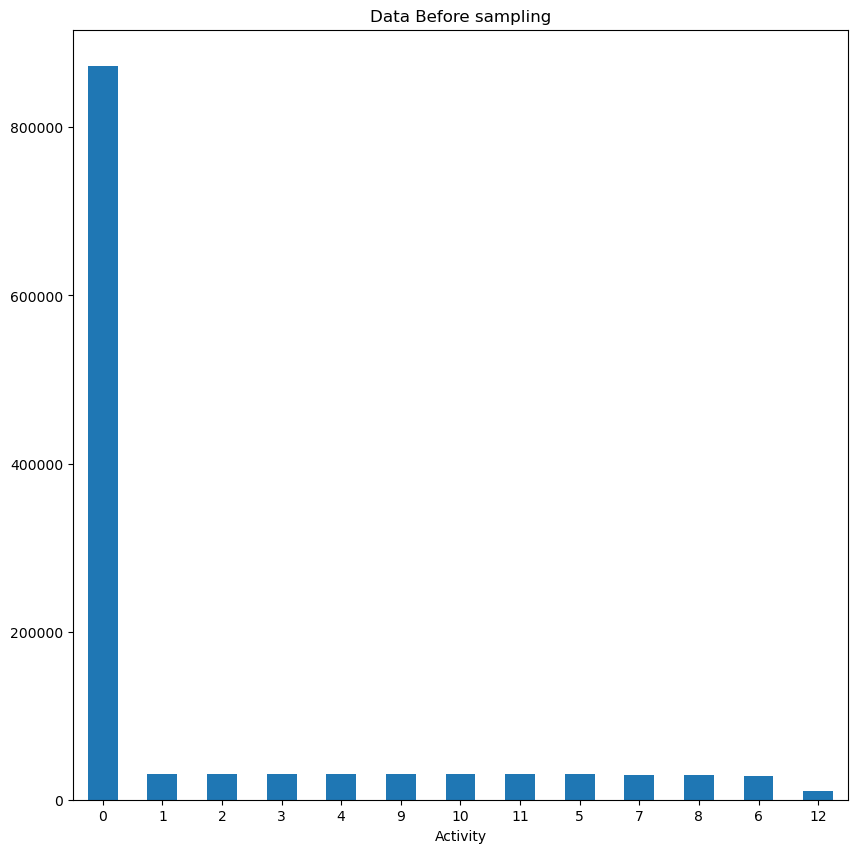

In [7]:
plt.figure(figsize=(10,10))
plt.title('Data Before sampling')
df['Activity'].value_counts().plot.bar(rot=0)

In [8]:
data_activity_0 = df[df['Activity'] == 0]
data_activity_else = df[df['Activity'] != 0]

data_activity_0 = data_activity_0.sample(n=40000, random_state=42)
df = pd.concat([data_activity_0, data_activity_else])

<Axes: title={'center': 'Data afetr sampling'}, xlabel='Activity'>

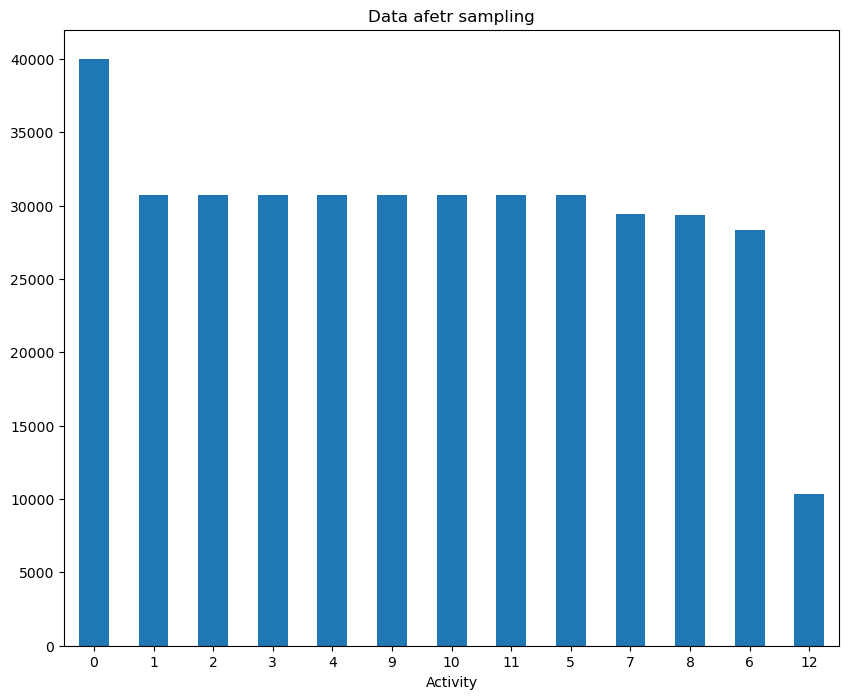

In [9]:
plt.figure(figsize=(10 ,8 ))
plt.title('Data afetr sampling')
df['Activity'].value_counts().plot.bar(rot=0)

In [10]:
activities_label = {
    0: "None",
    1: "Standing still (1 min)",
    2: "Sitting and relaxing (1 min)",
    3: "Lying down (1 min)",
    4: "Walking (1 min)",
    5: "Climbing stairs (1 min)",
    6: "Waist bends forward (20x)",
    7: "Frontal elevation of arms (20x)",
    8: "Knees bending (crouching) (20x)",
    9: "Cycling (1 min)",
    10: "Jogging (1 min)",
    11: "Running (1 min)",
    12: "Jump front & back (20x)"
}

In [11]:
df

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
1212350,1.33590,-9.7394,-1.66110,0.58813,-0.58724,-0.662080,-3.2703,-9.05310,-0.30682,0.401960,-1.06160,0.146550,0,subject10
134482,2.52730,-12.7320,-3.88220,0.51763,-0.58537,-0.758350,-4.3463,-10.51300,1.71390,-0.272550,-0.76591,0.851290,0,subject1
820343,0.55205,-9.7466,1.58070,0.55288,-0.76173,-0.176820,-5.8155,-8.16430,-2.42900,0.137250,-0.99795,0.521550,0,subject7
718210,2.49960,-9.3680,1.81700,0.73655,-0.55159,0.068762,-3.0504,-5.91350,4.65220,0.084314,-0.71047,0.900860,0,subject6
118798,-3.48370,-9.2520,0.54423,-0.37662,-0.61163,0.609040,-6.5952,-0.79894,7.10590,-0.900000,1.14580,0.818970,0,subject1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213641,-2.48730,-19.2330,3.46140,0.61967,-0.33771,-0.827110,-8.2348,-4.96520,2.48090,-0.437250,-1.01850,0.079741,12,subject10
1213642,-21.59100,-19.4370,-6.04190,0.61967,-0.33771,-0.827110,-21.3180,-10.21300,3.65600,-0.437250,-1.01850,0.079741,12,subject10
1213643,7.54330,-19.2450,-2.66800,0.61967,-0.33771,-0.827110,-21.2970,-18.70500,4.46060,-0.437250,-1.01850,0.079741,12,subject10
1213644,3.01420,-19.3340,-7.70740,0.71058,-0.27017,-0.754420,-21.1380,-18.69800,1.15880,-0.425490,-1.03700,0.084052,12,subject10


In [12]:
df['Activity'] = df['Activity'].replace([0,1,2,3,4,5,6,7,8,9,10,11,12],['None','Standing still (1 min)', 'Sitting and relaxing (1 min)', 'Lying down (1 min)', 'Walking (1 min)','Climbing stairs (1 min)','Waist bends forward (20x)','Frontal elevation of arms (20x)','Knees bending (crouching) (20x)','Cycling (1 min)','Jogging (1 min)','Running (1 min)','Jump front & back (20x)'])
df['Activity']

1212350                       None
134482                        None
820343                        None
718210                        None
118798                        None
                    ...           
1213641    Jump front & back (20x)
1213642    Jump front & back (20x)
1213643    Jump front & back (20x)
1213644    Jump front & back (20x)
1213645    Jump front & back (20x)
Name: Activity, Length: 383195, dtype: object

In [13]:
df.head()

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
1212350,1.33590,-9.7394,-1.66110,0.58813,-0.58724,-0.662080,-3.2703,-9.05310,-0.30682,0.401960,-1.06160,0.14655,None,subject10
134482,2.52730,-12.7320,-3.88220,0.51763,-0.58537,-0.758350,-4.3463,-10.51300,1.71390,-0.272550,-0.76591,0.85129,None,subject1
820343,0.55205,-9.7466,1.58070,0.55288,-0.76173,-0.176820,-5.8155,-8.16430,-2.42900,0.137250,-0.99795,0.52155,None,subject7
718210,2.49960,-9.3680,1.81700,0.73655,-0.55159,0.068762,-3.0504,-5.91350,4.65220,0.084314,-0.71047,0.90086,None,subject6
118798,-3.48370,-9.2520,0.54423,-0.37662,-0.61163,0.609040,-6.5952,-0.79894,7.10590,-0.900000,1.14580,0.81897,None,subject1


In [14]:
df=df.drop(columns=['subject'])

In [15]:
df.head()

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity
1212350,1.33590,-9.7394,-1.66110,0.58813,-0.58724,-0.662080,-3.2703,-9.05310,-0.30682,0.401960,-1.06160,0.14655,None
134482,2.52730,-12.7320,-3.88220,0.51763,-0.58537,-0.758350,-4.3463,-10.51300,1.71390,-0.272550,-0.76591,0.85129,None
820343,0.55205,-9.7466,1.58070,0.55288,-0.76173,-0.176820,-5.8155,-8.16430,-2.42900,0.137250,-0.99795,0.52155,None
718210,2.49960,-9.3680,1.81700,0.73655,-0.55159,0.068762,-3.0504,-5.91350,4.65220,0.084314,-0.71047,0.90086,None
118798,-3.48370,-9.2520,0.54423,-0.37662,-0.61163,0.609040,-6.5952,-0.79894,7.10590,-0.900000,1.14580,0.81897,None


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 383195 entries, 1212350 to 1213645
Data columns (total 13 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   alx       383195 non-null  float64
 1   aly       383195 non-null  float64
 2   alz       383195 non-null  float64
 3   glx       383195 non-null  float64
 4   gly       383195 non-null  float64
 5   glz       383195 non-null  float64
 6   arx       383195 non-null  float64
 7   ary       383195 non-null  float64
 8   arz       383195 non-null  float64
 9   grx       383195 non-null  float64
 10  gry       383195 non-null  float64
 11  grz       383195 non-null  float64
 12  Activity  383195 non-null  object 
dtypes: float64(12), object(1)
memory usage: 40.9+ MB


In [17]:
labelencoder=LabelEncoder()
df['Activity']=labelencoder.fit_transform(df['Activity'])
df['Activity']

1212350    7
134482     7
820343     7
718210     7
118798     7
          ..
1213641    4
1213642    4
1213643    4
1213644    4
1213645    4
Name: Activity, Length: 383195, dtype: int64

In [18]:
df['Activity'].unique()

array([ 7, 10,  9,  6, 12, 11,  2,  5,  1,  3,  8,  4,  0])

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
s=StandardScaler()

df

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity
1212350,1.33590,-9.7394,-1.66110,0.58813,-0.58724,-0.662080,-3.2703,-9.05310,-0.30682,0.401960,-1.06160,0.146550,7
134482,2.52730,-12.7320,-3.88220,0.51763,-0.58537,-0.758350,-4.3463,-10.51300,1.71390,-0.272550,-0.76591,0.851290,7
820343,0.55205,-9.7466,1.58070,0.55288,-0.76173,-0.176820,-5.8155,-8.16430,-2.42900,0.137250,-0.99795,0.521550,7
718210,2.49960,-9.3680,1.81700,0.73655,-0.55159,0.068762,-3.0504,-5.91350,4.65220,0.084314,-0.71047,0.900860,7
118798,-3.48370,-9.2520,0.54423,-0.37662,-0.61163,0.609040,-6.5952,-0.79894,7.10590,-0.900000,1.14580,0.818970,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213641,-2.48730,-19.2330,3.46140,0.61967,-0.33771,-0.827110,-8.2348,-4.96520,2.48090,-0.437250,-1.01850,0.079741,4
1213642,-21.59100,-19.4370,-6.04190,0.61967,-0.33771,-0.827110,-21.3180,-10.21300,3.65600,-0.437250,-1.01850,0.079741,4
1213643,7.54330,-19.2450,-2.66800,0.61967,-0.33771,-0.827110,-21.2970,-18.70500,4.46060,-0.437250,-1.01850,0.079741,4
1213644,3.01420,-19.3340,-7.70740,0.71058,-0.27017,-0.754420,-21.1380,-18.69800,1.15880,-0.425490,-1.03700,0.084052,4


In [21]:
x=df.iloc[:,:12]
y=df.iloc[:,12]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25)

x_train=s.fit_transform(x_train)
x_test=s.fit_transform(x_test)
y_train

303503      9
762390      7
206140     10
78086       1
581508      3
           ..
662821      6
813110      2
669928     12
658190      9
1187726     1
Name: Activity, Length: 287396, dtype: int64

In [22]:
from sklearn.linear_model import LinearRegression
linearreg=LinearRegression()

In [23]:
linearreg.fit(x_train,y_train)
y_pred_linearreg = linearreg.predict(x_test)
y_pred_linearreg=y_pred_linearreg.round(0)
y_pred_linearreg

array([3., 6., 8., ..., 8., 6., 6.])

In [24]:
import seaborn as sns
def resultsSummarizer(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    sensitivity = recall_score(y_true,y_pred,average='macro')
    
    
    plt.figure(figsize=(13, 12))
    
    sns.heatmap(cm,
                annot=True,
                cmap='Blues',
                xticklabels=activities_label.values(),
                yticklabels=activities_label.values()
               ) 
    
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Activity')
    plt.ylabel('Actual Activity')
    plt.show()
    
    print(f'Accuracy Score: ' + '{:.4%}'.format(acc))
    print(f'Precision Score: ' + '{:.4%}'.format(prec))
    print(f'Recall Score: ' + '{:.4%}'.format(rec))
    print(f'F_1 Score: ' + '{:.4%}'.format(f1))
    print(f'Sensitvity: ' + '{:.4%}'.format(sensitivity))

/Users/vianykumar/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/vianykumar/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


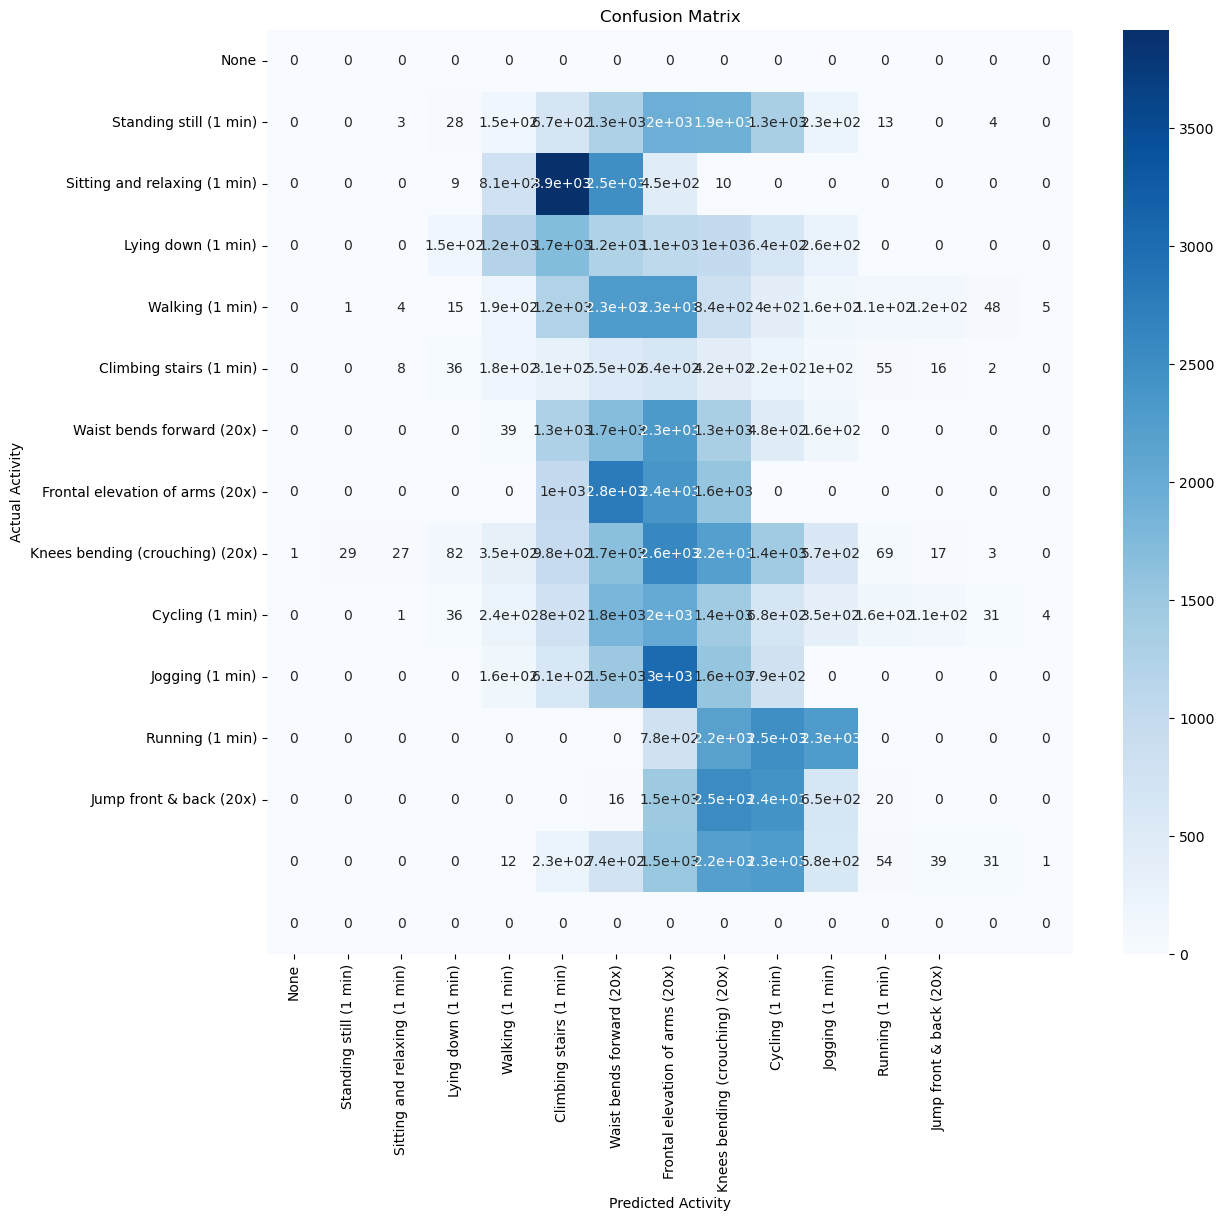

Accuracy Score: 7.9876%
Precision Score: 7.4922%
Recall Score: 6.7999%
F_1 Score: 4.1894%
Sensitvity: 6.7999%


In [25]:
from sklearn.metrics import classification_report
resultsSummarizer(y_test, y_pred_linearreg)

In [26]:
from sklearn.neighbors import KNeighborsClassifier
k1=KNeighborsClassifier(n_neighbors=6)
k1.fit(x_train,y_train)
# k1.score(x_train,y_train)
y_pred=k1.predict(x_test)
data=pd.DataFrame({'y_Test  ':y_test,'y_pred  ':y_pred})
data[:20]

,y_Test,y_pred
1173117,2,2
654950,10,10
806997,7,11
892453,12,12
786399,10,10
534605,10,10
654058,10,10
21769,6,6
88173,3,3
413097,7,7


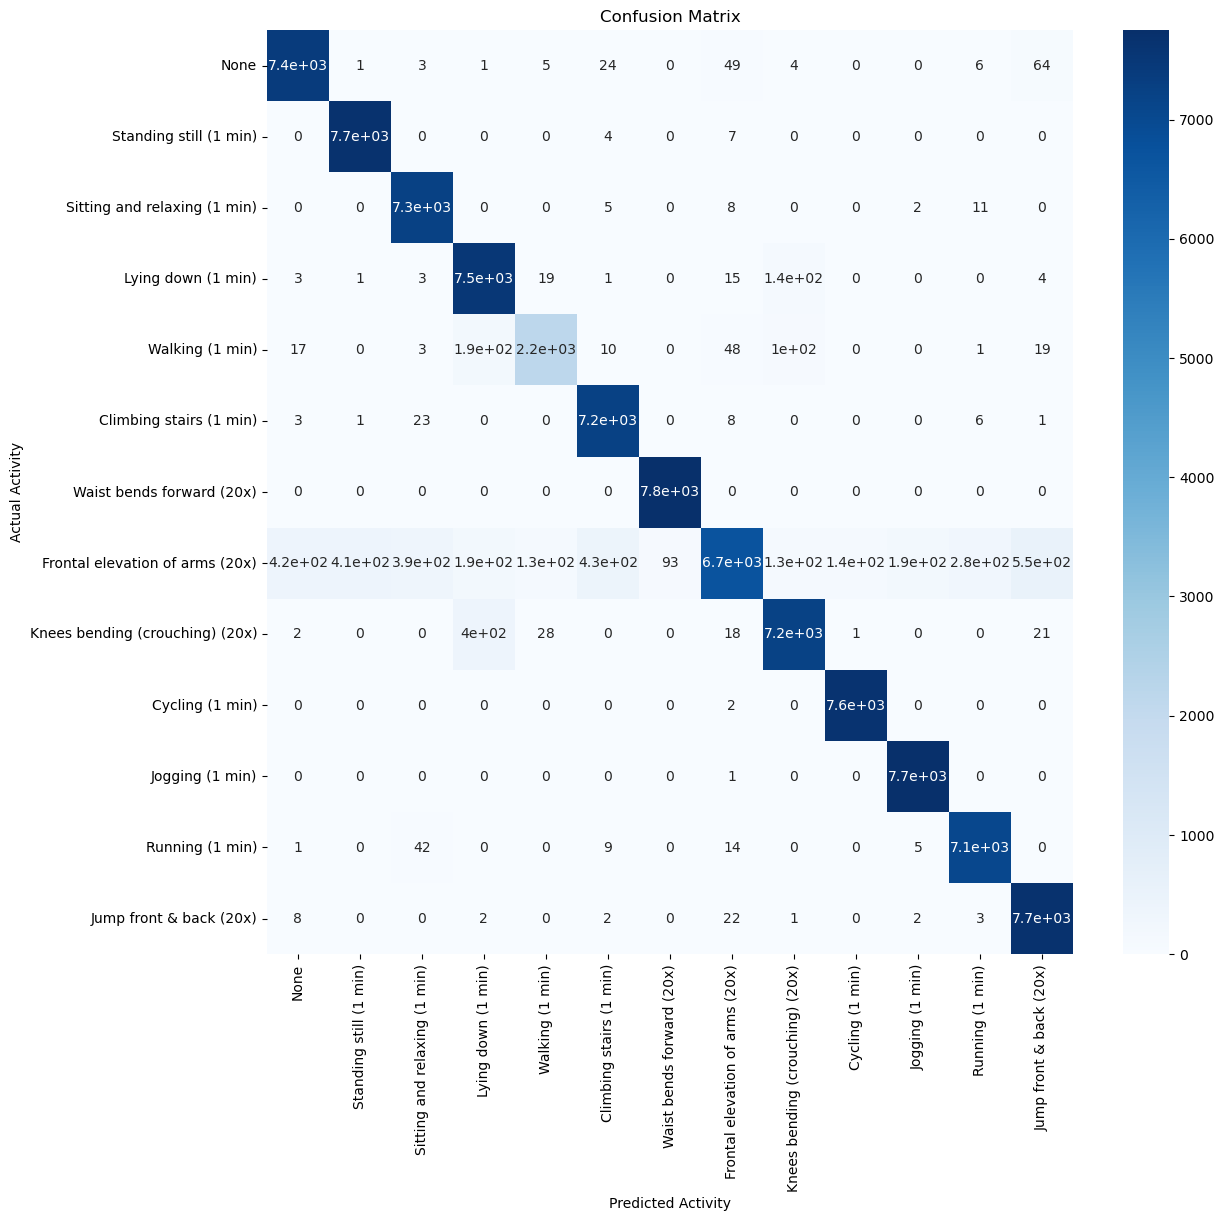

Accuracy Score: 95.0438%
Precision Score: 94.9528%
Recall Score: 95.2416%
F_1 Score: 94.8196%
Sensitvity: 95.2416%


In [27]:
resultsSummarizer(y_test, y_pred)